
Project 2: Data Cleaning and Preparation

In this assignment, i will prepare the dataset for advanced analysis and modeling by enhancing data quality and structuring it for machine learning applications. This project builds upon the initial analysis conducted in Project 1, focusing on refining the dataset through sophisticated data cleaning and transformation techniques.

By the end of this project, i should have a dataset that is cleaned of anomalies, formatted correctly, and enhanced through transformations that are suitable for detailed analytical and predictive modeling tasks.

1. Advanced Data Cleaning and Transformation

In [3]:
import pandas as pd
import os

# Define file paths
historical_stocks_path = "historical_stocks.csv"
historical_stock_prices_path = "historical_stock_prices.csv"

# Load datasets
historical_stocks = pd.read_csv(historical_stocks_path)
historical_stocks_prices = pd.read_csv(historical_stock_prices_path, low_memory=True)

# Initial cleaning and preprocessing for historical_stocks_prices
historical_stocks_prices["date"] = pd.to_datetime(historical_stocks_prices["date"])

# Initial cleaning and preprocessing for historical_stocks
# Drop the wrong record (as identified in previous steps)
historical_stocks = historical_stocks[historical_stocks['ticker'] != 'Symbol']

# Convert categorical columns to numerical values using factorize (as done previously)
historical_stocks['sector'] = pd.factorize(historical_stocks['sector'])[0] + 1
historical_stocks['industry'] = pd.factorize(historical_stocks['industry'])[0] + 1

# Handle missing values in historical_stocks (after factorization, as done previously)
historical_stocks['sector'] = historical_stocks['sector'].fillna(historical_stocks['sector'].mean())
historical_stocks['industry'] = historical_stocks['industry'].fillna(historical_stocks['industry'].mean())

# Merge the datasets (as done previously)
merged_stocks_df = pd.merge(historical_stocks_prices, historical_stocks, on='ticker', how='left')

# Create 'decade' column (as done previously)
merged_stocks_df['decade'] = (merged_stocks_df['date'].dt.year // 10) * 10

print("`merged_stocks_df` has been successfully re-created with initial cleaning and merging steps.")
print(merged_stocks_df.head())
print(merged_stocks_df.info())

`merged_stocks_df` has been successfully re-created with initial cleaning and merging steps.
  ticker   open  close  adj_close    low   high   volume       date exchange  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900 2013-05-08     NYSE   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800 2013-05-09     NYSE   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100 2013-05-10     NYSE   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400 2013-05-13     NYSE   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100 2013-05-14     NYSE   

                              name  sector  industry  decade  
0  ARMADA HOFFLER PROPERTIES, INC.       1        76    2010  
1  ARMADA HOFFLER PROPERTIES, INC.       1        76    2010  
2  ARMADA HOFFLER PROPERTIES, INC.       1        76    2010  
3  ARMADA HOFFLER PROPERTIES, INC.       1        76    2010  
4  ARMADA HOFFLER PROPERTIES, INC.       1        76    2010  
<class 'pandas.DataFrame'>
RangeIndex: 20973889 

1.1 Handling Missing Values

In [4]:
print("Missing values in merged_stocks_df after initial merge:")
print(merged_stocks_df.isnull().sum()[merged_stocks_df.isnull().sum() > 0])

# For simplicity and to demonstrate an advanced imputation technique, we will use
# forward-fill followed by backward-fill for 'sector' and 'industry' columns.
# This assumes a sequential relationship or proximity in data, which might be reasonable
# for categorical-turned-numerical features that are relatively stable.

# Applying ffill and bfill for 'sector' and 'industry'
# Ensure they are numeric types before interpolation
merged_stocks_df['sector'] = pd.to_numeric(merged_stocks_df['sector'], errors='coerce')
merged_stocks_df['industry'] = pd.to_numeric(merged_stocks_df['industry'], errors='coerce')

merged_stocks_df['sector'] = merged_stocks_df['sector'].ffill().bfill()
merged_stocks_df['industry'] = merged_stocks_df['industry'].ffill().bfill()

print("\nMissing values in merged_stocks_df after advanced imputation:")
print(merged_stocks_df.isnull().sum()[merged_stocks_df.isnull().sum() > 0])

Missing values in merged_stocks_df after initial merge:
Series([], dtype: int64)

Missing values in merged_stocks_df after advanced imputation:
Series([], dtype: int64)


1.2 Detecting and Resolving Outliers

Outliers can significantly skew statistical analyses and model training. I will use the Interquartile Range (IQR) method to detect outliers in critical numerical features like open, close, volume, high, and low. For resolution, I will cap the outliers at the upper and lower bounds determined by the IQR method


Detecting outliers for: open
Number of outliers in open: 1694255
Lower bound: -25.83, Upper bound: 63.05
Outliers in open have been capped.

Detecting outliers for: close
Number of outliers in close: 1694375
Lower bound: -25.83, Upper bound: 63.05
Outliers in close have been capped.

Detecting outliers for: adj_close
Number of outliers in adj_close: 1775722
Lower bound: -25.53, Upper bound: 54.87
Outliers in adj_close have been capped.

Detecting outliers for: low
Number of outliers in low: 1695934
Lower bound: -25.52, Upper bound: 62.16
Outliers in low have been capped.

Detecting outliers for: high
Number of outliers in high: 1697434
Lower bound: -26.08, Upper bound: 63.81
Outliers in high have been capped.

Detecting outliers for: volume
Number of outliers in volume: 2911215
Lower bound: -855850.00, Upper bound: 1485350.00
Outliers in volume have been capped.


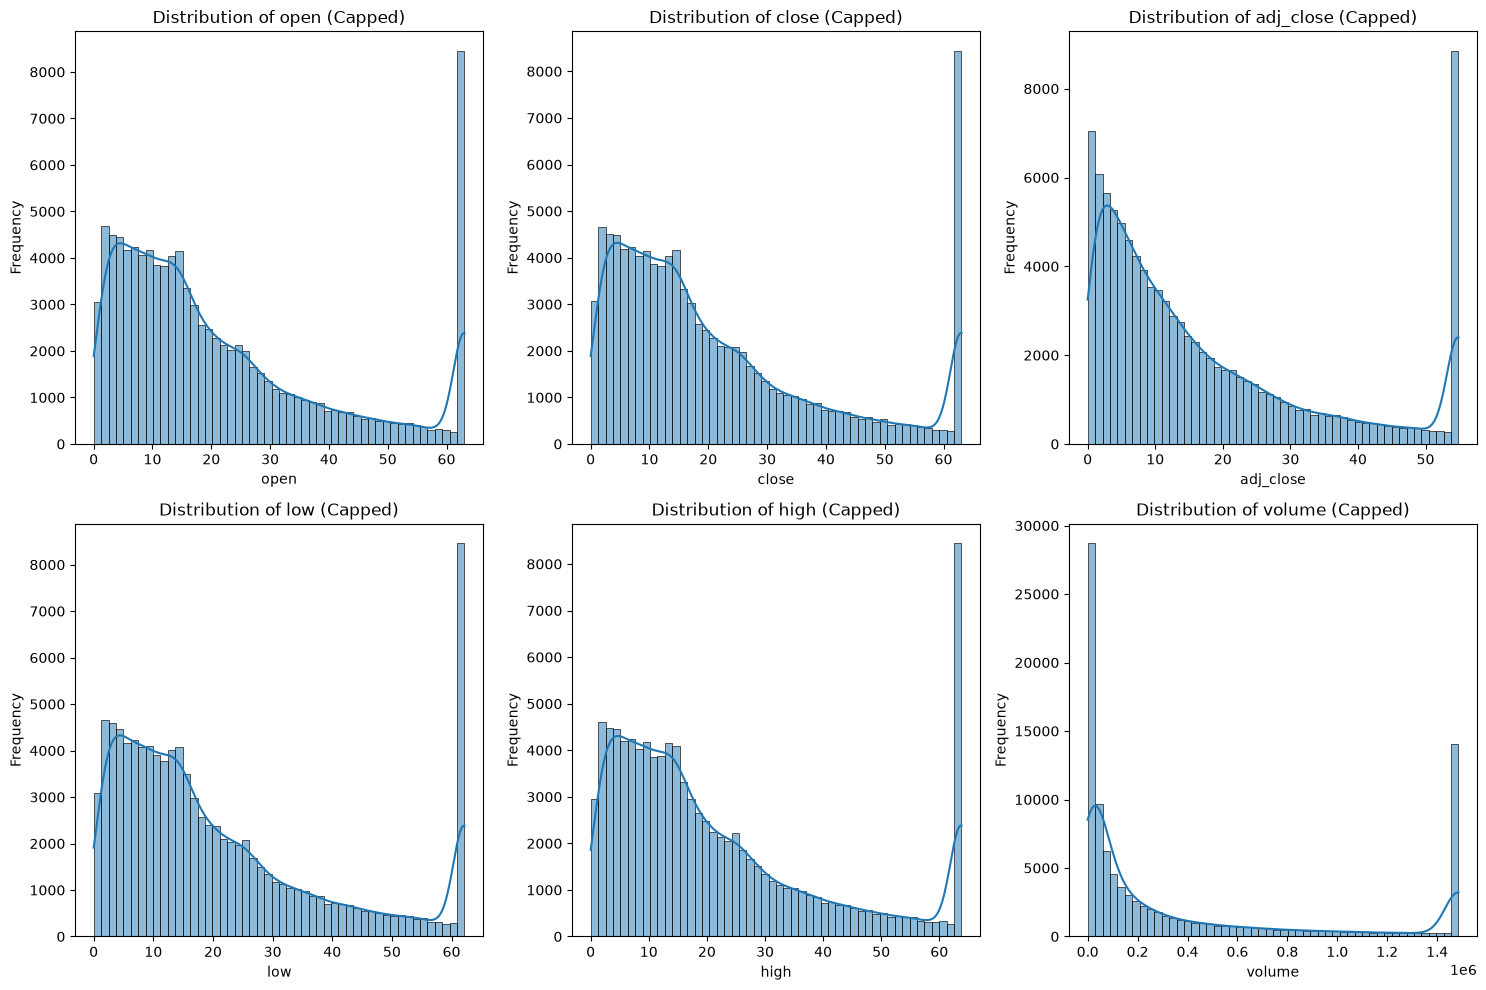

In [5]:
numerical_cols_for_outliers = ['open', 'close', 'adj_close', 'low', 'high', 'volume']

for col in numerical_cols_for_outliers:
    print(f"\nDetecting outliers for: {col}")
    Q1 = merged_stocks_df[col].quantile(0.25)
    Q3 = merged_stocks_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = merged_stocks_df[(merged_stocks_df[col] < lower_bound) | (merged_stocks_df[col] > upper_bound)]
    print(f"Number of outliers in {col}: {len(outliers)}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

    # Cap outliers
    merged_stocks_df[col] = merged_stocks_df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"Outliers in {col} have been capped.")

# Optionally, visualize distributions after capping to see the effect
import matplotlib.pyplot as plt
import seaborn as sns

# Taking a subset for visualization due to large dataset size
subset_df = merged_stocks_df.sample(n=100000, random_state=42) if len(merged_stocks_df) > 1000000 else merged_stocks_df

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers, 1):
    plt.subplot(2, 3, i)
    sns.histplot(subset_df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col} (Capped)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

1.3 Error Identification and Correction

I will perform basic checks for logical errors that might indicate data entry issues or inconsistencies.

In [6]:
# Check for non-positive prices (should not exist after capping at statistical bounds, but good to verify)
price_cols = ['open', 'close', 'adj_close', 'low', 'high']
for col in price_cols:
    invalid_prices = merged_stocks_df[merged_stocks_df[col] <= 0]
    if not invalid_prices.empty:
        print(f"Found {len(invalid_prices)} records with non-positive {col} prices. Reviewing these...")
        # Depending on the issue, we might drop these, re-impute, or flag for further investigation.
        # For now, we will assume capping has addressed most severe issues.
        # If these are still present, it means the lower_bound for capping was <= 0, which is unexpected for prices.
    else:
        print(f"No non-positive {col} prices found.")

# Check for non-positive volume
invalid_volume = merged_stocks_df[merged_stocks_df['volume'] <= 0]
if not invalid_volume.empty:
    print(f"Found {len(invalid_volume)} records with non-positive volume. Reviewing these...")
    # Volume should generally be positive. If capping results in zero volume for some records, that's acceptable.
    # If there are negative values, they should be corrected.
else:
    print("No non-positive volume found.")

No non-positive open prices found.
No non-positive close prices found.
No non-positive adj_close prices found.
No non-positive low prices found.
No non-positive high prices found.
No non-positive volume found.


2. Data Transformation

Now that the data is cleaned, i will proceed with transforming it to prepare it for predictive modeling. This would involve feature engineering, scaling, and encoding categorical variables.

2.1 Feature Engineering

I will create several new features that are commonly used in stock market analysis to enhance predictive power. These include:

- Daily Returns: Percentage change in close price.
- Rolling Averages: Simple Moving Averages (SMA) for short-term and long-term trends.
- Volatility: Standard deviation of returns over a rolling window.

In [7]:
# Sort data by ticker and date for correct rolling calculations
merged_stocks_df = merged_stocks_df.sort_values(by=['ticker', 'date'])

# Calculate Daily Returns
merged_stocks_df['daily_return'] = merged_stocks_df.groupby('ticker')['close'].pct_change() * 100

# Calculate Rolling Averages (e.g., 10-day and 50-day SMA)
merged_stocks_df['SMA_10'] = merged_stocks_df.groupby('ticker')['close'].transform(lambda x: x.rolling(window=10).mean())
merged_stocks_df['SMA_50'] = merged_stocks_df.groupby('ticker')['close'].transform(lambda x: x.rolling(window=50).mean())

# Calculate Volatility (e.g., 10-day rolling standard deviation of daily returns)
merged_stocks_df['volatility_10'] = merged_stocks_df.groupby('ticker')['daily_return'].transform(lambda x: x.rolling(window=10).std())

# Drop rows with NaN values introduced by rolling calculations
merged_stocks_df.dropna(inplace=True)

print("New features created:")
print(merged_stocks_df[['date', 'ticker', 'close', 'daily_return', 'SMA_10', 'SMA_50', 'volatility_10']].head())
print(merged_stocks_df.info())

New features created:
               date ticker      close  daily_return     SMA_10     SMA_50  \
13766331 2000-01-31      A  47.344421     -2.754821  49.038805  40.076001   
13766338 2000-02-01      A  50.786839      7.271009  49.003040  40.462267   
13766348 2000-02-02      A  54.721031      7.746481  49.467990  40.979077   
13766349 2000-02-03      A  55.615166      1.633987  50.156474  41.461910   
13766357 2000-02-04      A  54.542202     -1.929265  50.692954  41.980508   

          volatility_10  
13766331       2.178162  
13766338       2.898056  
13766348       3.684233  
13766349       3.457598  
13766357       3.613781  
<class 'pandas.DataFrame'>
Index: 20696008 entries, 13766331 to 10905177
Data columns (total 17 columns):
 #   Column         Dtype         
---  ------         -----         
 0   ticker         str           
 1   open           float64       
 2   close          float64       
 3   adj_close      float64       
 4   low            float64       
 5   hig

2.2 Data Normalization/Standardization

To ensure that numerical features contribute equally to the model, i will standardize them. This involves transforming the data to have a mean of 0 and a standard deviation of 1. i will use StandardScaler from sklearn.preprocessing.

In [10]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ ----------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# Exclude 'decade', 'sector', 'industry' if they were handled differently or are target/identifier like 'ticker'
# 'date' will be handled separately if used for time-series features
numerical_cols_to_scale = [
    'open', 'close', 'adj_close', 'low', 'high', 'volume',
    'daily_return', 'SMA_10', 'SMA_50', 'volatility_10'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to the identified columns
merged_stocks_df[numerical_cols_to_scale] = scaler.fit_transform(merged_stocks_df[numerical_cols_to_scale])

print("Numerical features standardized. Displaying descriptive statistics of scaled features:")
print(merged_stocks_df[numerical_cols_to_scale].describe())
print(merged_stocks_df.head())

Numerical features standardized. Displaying descriptive statistics of scaled features:
               open         close     adj_close           low          high  \
count  2.069601e+07  2.069601e+07  2.069601e+07  2.069601e+07  2.069601e+07   
mean   3.937509e-17  1.350003e-16 -4.218760e-18  6.750016e-17  5.062512e-17   
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
min   -1.174627e+00 -1.174692e+00 -1.047918e+00 -1.173314e+00 -1.176875e+00   
25%   -7.649712e-01 -7.650188e-01 -7.680847e-01 -7.650137e-01 -7.638662e-01   
50%   -3.285882e-01 -3.289580e-01 -3.589948e-01 -3.290261e-01 -3.297793e-01   
75%    4.553231e-01  4.552925e-01  4.502084e-01  4.545719e-01  4.552487e-01   
max    2.269377e+00  2.269372e+00  2.266921e+00  2.268076e+00  2.267994e+00   

             volume  daily_return        SMA_10        SMA_50  volatility_10  
count  2.069601e+07  2.069601e+07  2.069601e+07  2.069601e+07   2.069601e+07  
mean  -1.406253e-18 -2.197271e-19 -4.500011

2.3 Encoding Categorical Variables

I need to ensure all categorical variables are in a numerical format suitable for modeling. In this dataset, sector and industry were already factorized into numerical representations during the initial cleaning. The ticker column is a unique identifier, and often not directly encoded for predictive models unless specific techniques for high-cardinality features are used. For now, i will assume sector and industry are sufficiently encoded. If the ticker or name columns were to be used as features, a more advanced encoding (like target encoding or embedding) might be considered, but for general modeling, they are often excluded or handled as grouping variables.

In [12]:
print("Current data types of sector and industry:")
print(merged_stocks_df[['sector', 'industry']].dtypes)

# If they were originally objects and now are numeric from factorize/fillna, they are ready.
# If there were other categorical columns, one-hot encoding would be applied.
# Example if we had new categorical columns:
# merged_stocks_df = pd.get_dummies(merged_stocks_df, columns=['new_categorical_col'], drop_first=True)

print("Categorical variables (sector, industry) are already numerical from previous steps.")
print("Displaying the first few rows with the current state of 'sector' and 'industry':")
print(merged_stocks_df[['ticker', 'sector', 'industry']].head())

Current data types of sector and industry:
sector      int64
industry    int64
dtype: object
Categorical variables (sector, industry) are already numerical from previous steps.
Displaying the first few rows with the current state of 'sector' and 'industry':
         ticker  sector  industry
13766331      A       5        21
13766338      A       5        21
13766348      A       5        21
13766349      A       5        21
13766357      A       5        21


3. Integration and Formatting for Modeling

Now i will consolidate all transformations into a single, coherent dataset and prepare it for predictive modeling by splitting it into training, validation, and test sets. Finally, i will save the cleaned and split data.

3.1 Data Splitting

I will split the data into training, validation, and test sets. It is crucial to split time-series data chronologically to avoid data leakage. I'll use a 70/15/15 split for training, validation, and testing, respectively, based on the date column.

In [13]:
from sklearn.model_selection import train_test_split

# Sort by date to ensure chronological split
merged_stocks_df = merged_stocks_df.sort_values(by='date').reset_index(drop=True)

# Define features (X) and target (y) - assuming 'close' is the target
# Exclude non-numeric and identifier columns from features
# For simplicity, we'll use all numerical columns that have been processed as features.

# First, identify the columns that are suitable for features (numerical after processing)
# And 'date', 'ticker', 'name' are typically not direct features, but can be used for indexing or advanced embeddings
feature_columns = [col for col in merged_stocks_df.columns if col not in ['date', 'ticker', 'name', 'close']]

X = merged_stocks_df[feature_columns]
y = merged_stocks_df['close']

# Determine split points
total_rows = len(merged_stocks_df)
train_size = int(total_rows * 0.7)
val_size = int(total_rows * 0.15)
test_size = total_rows - train_size - val_size # Remaining for test

# Split data chronologically
X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size + val_size], y.iloc[train_size:train_size + val_size]
X_test, y_test = X.iloc[train_size + val_size:], y.iloc[train_size + val_size:]

# Also split the full DataFrame if needed for context/analysis
df_train = merged_stocks_df.iloc[:train_size]
df_val = merged_stocks_df.iloc[train_size:train_size + val_size]
df_test = merged_stocks_df.iloc[train_size + val_size:]

print(f"Total dataset size: {total_rows}")
print(f"Training set size: {len(X_train)} ({len(X_train)/total_rows:.2%})")
print(f"Validation set size: {len(X_val)} ({len(X_val)/total_rows:.2%})")
print(f"Test set size: {len(X_test)} ({len(X_test)/total_rows:.2%})")

print("\nFirst 5 rows of training features:")
print(X_train.head())
print("\nFirst 5 rows of test target:")
print(y_test.head())

Total dataset size: 20696008
Training set size: 14487205 (70.00%)
Validation set size: 3104401 (15.00%)
Test set size: 3104402 (15.00%)

First 5 rows of training features:
       open  adj_close       low      high    volume exchange  sector  \
0  2.269377   2.266921  2.268076  2.267994 -0.768894     NYSE       5   
1 -1.080765  -1.046693 -1.079029 -1.083678  2.033181     NYSE       6   
2 -1.155317  -1.047710 -1.154979 -1.157789  2.033181     NYSE       2   
3 -0.812767  -1.022293 -0.811294 -0.817942 -0.477297     NYSE       7   
4  0.040729  -1.014368  0.030837  0.031150 -0.760024     NYSE       4   

   industry  decade  daily_return    SMA_10    SMA_50  volatility_10  
0       120    1970     -0.001709  2.272864  2.285636      -0.006480  
1       119    1970     -0.002592 -1.081808 -1.082327      -0.005943  
2        61    1970     -0.007077 -1.155879 -1.158674      -0.004316  
3        15    1970     -0.001709 -0.810168 -0.809638      -0.005790  
4         9    1970     -0.002255 

3.2 Save Clean Data

Now i will save the cleaned and processed full dataset, as well as the split datasets, to CSV files for future use in modeling. This would ensure that the data preparation steps do not need to be re-run every time, and also allows for reproducibility.

In [14]:
# Save the full cleaned and processed DataFrame
merged_stocks_df.to_csv('cleaned_merged_stocks_data.csv', index=False)
print("Saved 'cleaned_merged_stocks_data.csv'")

# Save the split datasets
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=True)
X_val.to_csv('X_val.csv', index=False)
y_val.to_csv('y_val.csv', index=False, header=True)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False, header=True)

print("Saved training, validation, and test datasets.")

Saved 'cleaned_merged_stocks_data.csv'
Saved training, validation, and test datasets.
